# Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Phishing_URL_ds_5percent_missing.csv").drop(columns=["FILENAME"])
with pd.option_context("display.max_columns", None):
    display(data.head())

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31.0,NaN,24.0,0.0,com,100.0,1.000000,0.522907,0.061933,3.0,1.0,0.0,0.0,0.0,18.0,0.581,0.0,0.0,0.0,0.0,0.0,1.0,0.032,NaN,558.0,9381.0,1.0,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,34.0,20.0,NaN,119.0,0.0,124.0,1.0
1,https://www.uni-mainz.de,23.0,www.uni-mainz.de,16.0,0.0,NaN,100.0,0.666667,0.032650,0.050207,2.0,1.0,0.0,0.0,0.0,9.0,0.391,0.0,0.0,0.0,0.0,0.0,2.0,0.087,1.0,618.0,9381.0,1.0,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,9.0,8.0,39.0,0.0,217.0,1.0
2,https://www.voicefmradio.co.uk,NaN,www.voicefmradio.co.uk,22.0,0.0,uk,100.0,0.866667,0.028555,0.064129,2.0,2.0,0.0,NaN,0.0,15.0,0.517,0.0,0.0,0.0,0.0,0.0,2.0,0.069,1.0,467.0,682.0,1.0,voice fm southampton,46.666667,46.666667,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,10.0,2.0,7.0,42.0,2.0,5.0,1.0
3,https://www.sfnmjournal.com,26.0,www.sfnmjournal.com,19.0,0.0,com,100.0,1.000000,0.522907,NaN,3.0,1.0,NaN,0.0,0.0,13.0,0.500,0.0,0.0,0.0,0.0,NaN,1.0,0.038,NaN,6356.0,26824.0,1.0,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,1.0,12.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,NaN,3.0,27.0,15.0,22.0,1.0,31.0,1.0
4,https://www.rewildingargentina.org,33.0,www.rewildingargentina.org,26.0,0.0,org,100.0,1.000000,0.079963,0.059441,3.0,1.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.030,1.0,6089.0,28404.0,1.0,fundaciÃ³n rewilding argentina,100.000000,100.000000,0.0,1.0,1.0,1.0,1.0,1.0,0.0,2.0,0.0,1.0,1.0,NaN,0.0,1.0,1.0,0.0,1.0,244.0,15.0,34.0,72.0,1.0,85.0,1.0


In [3]:
data.select_dtypes(include="object").head()

,URL,Domain,TLD,Title
0,https://www.southbankmosaics.com,NaN,com,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...
1,https://www.uni-mainz.de,www.uni-mainz.de,NaN,johannes gutenberg-universitÃ¤t mainz
2,https://www.voicefmradio.co.uk,www.voicefmradio.co.uk,uk,voice fm southampton
3,https://www.sfnmjournal.com,www.sfnmjournal.com,com,home page: seminars in fetal and neonatal medi...
4,https://www.rewildingargentina.org,www.rewildingargentina.org,org,fundaciÃ³n rewilding argentina


In [4]:
with pd.option_context("display.max_columns", None):
    display(data[data["NoOfEqualsInURL"] > 0].head())

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
31,NaN,91.0,ipfs.io,7.0,0.0,io,9.669201,1.000000,0.012927,0.041483,2.0,0.0,0.0,0.0,0.0,69.0,0.758,7.0,0.077,1.0,1.0,0.0,5.0,0.077,1.0,105.0,1607.0,1.0,roundcube webmail :: welcome to roundcube webmail,0.0,2.531646,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,6.0,0.0,0.0,2.0,0.0
45,https://pontosapontamentolu.com/gclid/=/c/?gcl...,140.0,pontosapontamentolu.com,23.0,0.0,com,9.203795,1.000000,0.522907,0.037272,3.0,0.0,0.0,0.0,0.0,99.0,0.707,19.0,0.136,2.0,1.0,0.0,11.0,NaN,1.0,11.0,148.0,1.0,pontosapontamentolugclid=c?gclid=ishecabh95cvb...,0.0,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
91,http://tkmowpikuk.owl4fsrch.club/vnafvra97w/?q...,64.0,tkmowpikuk.owl4fsrch.club,25.0,0.0,club,14.338629,0.600000,0.000623,0.028541,4.0,1.0,0.0,0.0,0.0,33.0,0.516,16.0,0.250,2.0,1.0,NaN,5.0,0.125,0.0,2.0,72.0,0.0,0,0.0,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
167,https://acesseonline-fevereiro.net/luiza/?user...,98.0,acesseonline-fevereiro.net,26.0,0.0,net,13.534120,0.590909,0.038420,0.045336,3.0,0.0,0.0,0.0,0.0,74.0,0.755,6.0,0.061,3.0,1.0,0.0,NaN,0.102,1.0,2.0,106.0,0.0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
212,https://visualize-detalhes-online.com/luiza/?u...,73.0,visualize-detalhes-online.com,29.0,0.0,com,26.192728,0.400000,0.522907,0.048629,3.0,0.0,0.0,0.0,0.0,53.0,0.726,2.0,0.027,2.0,1.0,0.0,7.0,0.137,1.0,90.0,394.0,NaN,NaN,0.0,98.333333,0.0,1.0,1.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,2.0,0.0,2.0,0.0,2.0,0.0


URL can contain `=` signs freely as it is part of the standard itself and nothing about it is malicious. This features would not be meaningful.

In [5]:
from sklearn.preprocessing import LabelEncoder
from joblib import Parallel, delayed

data["NoOfDigitsInDomain"] = data["Domain"].str.count(r"\d")
data["DigitRatioInDomain"] = data["NoOfDigitsInDomain"] / data["DomainLength"]
data["NoOfHyphensInDomain"] = data["Domain"].str.count("-")
data["HyphenRatioInDomain"] = data["NoOfHyphensInDomain"] / data["DomainLength"]
data["NoOfSpecialCharInDomain"] = data["Domain"].str.count(r"[^a-zA-Z0-9\.-]")
data["AlphabetRatioInDomain"] = (
    data["Domain"].str.count(r"[a-zA-Z]") / data["DomainLength"]
)
data["NoOfTokensInDomain"] = (
    data["Domain"]
    .fillna("")
    .str.split(r"[.-]")
    .apply(lambda x: len([t for t in x if t]))
)


# I am not sure about this feature, but we may try it as well
def shannon_entropy(s):
    if not isinstance(s, str) or len(s) == 0:
        # Better to return None than zero
        return None

    le = LabelEncoder()
    encoded = le.fit_transform(list(s))

    counts = np.bincount(encoded)
    probs = counts[counts > 0] / counts.sum()

    # Shannon entropy (base 2)
    return -np.sum(probs * np.log2(probs + 1e-12))


data["DomainEntropy"] = Parallel(n_jobs=-1, backend="loky")(
    delayed(shannon_entropy)(d) for d in data["Domain"].values
)

Fix the `TLD` feature.

In [6]:
import re
from urllib.parse import urlparse
from joblib import Parallel, delayed

ipv4_re = re.compile(r"^\d{1,3}(\.\d{1,3}){3}$")
ipv6_re = re.compile(r"^\[?[0-9a-fA-F:]+\]?$")


def extract_url_features(url):
    out = {
        "TLD": None,
        "TLDLength": 0,
        "IsDomainIP": 0,
        "IsHTTPS": 0,
        "NoOfSubDomain": 0,
    }

    if pd.isna(url):
        return out

    try:
        parsed = urlparse(url if "://" in url else "http://" + url)

        host = parsed.hostname
        if host is None:
            return out

        # HTTPS
        out["IsHTTPS"] = int(parsed.scheme.lower() == "https")

        # IP detection
        if ipv4_re.match(host) or ipv6_re.match(host):
            out["IsDomainIP"] = 1
            return out

        parts = host.lower().split(".")

        if len(parts) < 2:
            return out

        tld = parts[-1]

        # TLD sanity check
        if not tld.isalpha():
            return out

        out["TLD"] = tld
        out["TLDLength"] = len(tld)

        # subdomains = everything before (domain + tld)
        out["NoOfSubDomain"] = max(len(parts) - 2, 0)

        return out

    except Exception:
        return out


features = Parallel(n_jobs=-1, backend="loky")(
    delayed(extract_url_features)(u) for u in data["URL"].values
)
features = pd.DataFrame(features)

data[features.columns] = features

In [7]:
new_features = [
    "NoOfDigitsInDomain",
    "DigitRatioInDomain",
    "NoOfHyphensInDomain",
    "HyphenRatioInDomain",
    "NoOfSpecialCharInDomain",
    "AlphabetRatioInDomain",
    "NoOfTokensInDomain",
    "DomainEntropy",
]

data[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
NoOfDigitsInDomain,224040.0,0.881642,2.788403,0.000000,0.000000,0.000000,0.000000,44.000000
DigitRatioInDomain,212764.0,0.031090,0.092012,0.000000,0.000000,0.000000,0.000000,0.885714
NoOfHyphensInDomain,224040.0,0.281651,0.751233,0.000000,0.000000,0.000000,0.000000,26.000000
HyphenRatioInDomain,212764.0,0.009931,0.023497,0.000000,0.000000,0.000000,0.000000,0.419355
NoOfSpecialCharInDomain,224040.0,0.000174,0.015087,0.000000,0.000000,0.000000,0.000000,2.000000
AlphabetRatioInDomain,212764.0,0.848039,0.101197,0.000000,0.833333,0.875000,0.900000,0.978723
NoOfTokensInDomain,235795.0,3.270230,1.235126,0.000000,3.000000,3.000000,4.000000,29.000000
DomainEntropy,224040.0,3.471831,0.400791,0.721928,3.202820,3.471354,3.720176,4.975311


In [8]:
with pd.option_context("display.max_rows", None):
    display(pd.Series(data.columns))

0                            URL
1                      URLLength
2                         Domain
3                   DomainLength
4                     IsDomainIP
5                            TLD
6             URLSimilarityIndex
7           CharContinuationRate
8              TLDLegitimateProb
9                    URLCharProb
10                     TLDLength
11                 NoOfSubDomain
12                HasObfuscation
13            NoOfObfuscatedChar
14              ObfuscationRatio
15              NoOfLettersInURL
16              LetterRatioInURL
17               NoOfDegitsInURL
18               DegitRatioInURL
19               NoOfEqualsInURL
20                NoOfQMarkInURL
21            NoOfAmpersandInURL
22    NoOfOtherSpecialCharsInURL
23         SpacialCharRatioInURL
24                       IsHTTPS
25                    LineOfCode
26             LargestLineLength
27                      HasTitle
28                         Title
29         DomainTitleMatchScore
30        

In [9]:
features_to_remove = [
    # We remove the URL based features, because URLs in real life can be anything and may not really tell us anything about phishingness. The domain would be better.
    "URL",
    "URLLength",
    "URLSimilarityIndex",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",

    # We apply encoding ourselves.
    "TLDLegitimateProb",

    "Title",
]

data = data.drop(columns=features_to_remove)

In [10]:
with pd.option_context("display.max_rows", None):
    display(pd.Series(data.columns))

0                      Domain
1                DomainLength
2                  IsDomainIP
3                         TLD
4        CharContinuationRate
5                 URLCharProb
6                   TLDLength
7               NoOfSubDomain
8              HasObfuscation
9          NoOfObfuscatedChar
10           ObfuscationRatio
11                    IsHTTPS
12                 LineOfCode
13          LargestLineLength
14                   HasTitle
15      DomainTitleMatchScore
16         URLTitleMatchScore
17                 HasFavicon
18                     Robots
19               IsResponsive
20            NoOfURLRedirect
21           NoOfSelfRedirect
22             HasDescription
23                  NoOfPopup
24                 NoOfiFrame
25      HasExternalFormSubmit
26               HasSocialNet
27            HasSubmitButton
28            HasHiddenFields
29           HasPasswordField
30                       Bank
31                        Pay
32                     Crypto
33        

In [11]:
binary_columns = [col for col in data.columns if data[col].dropna().nunique() == 2]
binary_columns

['IsDomainIP',
 'HasObfuscation',
 'IsHTTPS',
 'HasTitle',
 'HasFavicon',
 'Robots',
 'IsResponsive',
 'NoOfURLRedirect',
 'NoOfSelfRedirect',
 'HasDescription',
 'HasExternalFormSubmit',
 'HasSocialNet',
 'HasSubmitButton',
 'HasHiddenFields',
 'HasPasswordField',
 'Bank',
 'Pay',
 'Crypto',
 'HasCopyrightInfo',
 'label']

In [12]:
data = data.rename(
    columns={
        "NoOfURLRedirect": "HasURLRedirect",
        "NoOfSelfRedirect": "HasSelfRedirect",
    }
)
binary_columns = [col for col in data.columns if data[col].dropna().nunique() == 2]

In [13]:
data[binary_columns] = data[binary_columns].astype("Int8")

In [14]:
discrete_columns = [col for col in data.columns if col.startswith("NoOf") | ("Length" in col)]
discrete_columns.append("LineOfCode")
np.setdiff1d(data.columns, np.union1d(discrete_columns, binary_columns))

array(['AlphabetRatioInDomain', 'CharContinuationRate',
       'DigitRatioInDomain', 'Domain', 'DomainEntropy',
       'DomainTitleMatchScore', 'HyphenRatioInDomain', 'ObfuscationRatio',
       'TLD', 'URLCharProb', 'URLTitleMatchScore'], dtype=object)

In [15]:
data[discrete_columns] = data[discrete_columns].astype("Int64")

In [16]:
object_columns = [col for col in data.columns if data.dtypes[col] == "object"]
object_columns

['Domain', 'TLD']

In [17]:
from functools import reduce
float_columns = np.setdiff1d(data.columns, reduce(np.union1d, (binary_columns, discrete_columns, object_columns)))
float_columns

array(['AlphabetRatioInDomain', 'CharContinuationRate',
       'DigitRatioInDomain', 'DomainEntropy', 'DomainTitleMatchScore',
       'HyphenRatioInDomain', 'ObfuscationRatio', 'URLCharProb',
       'URLTitleMatchScore'], dtype=object)

# Check Almost Binary Variables

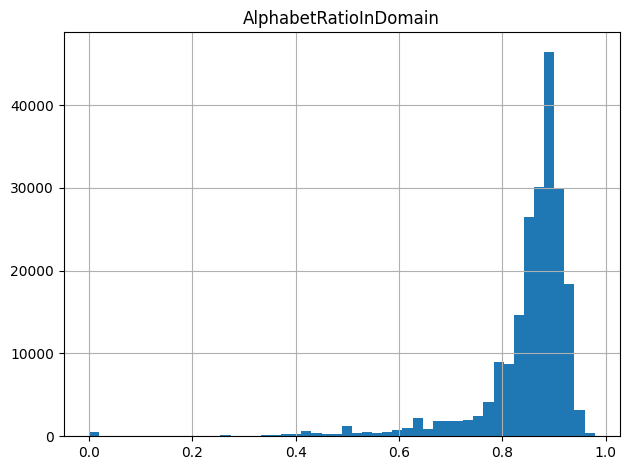

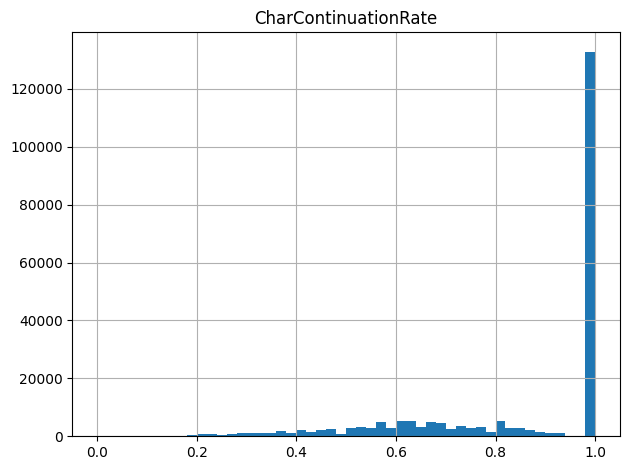

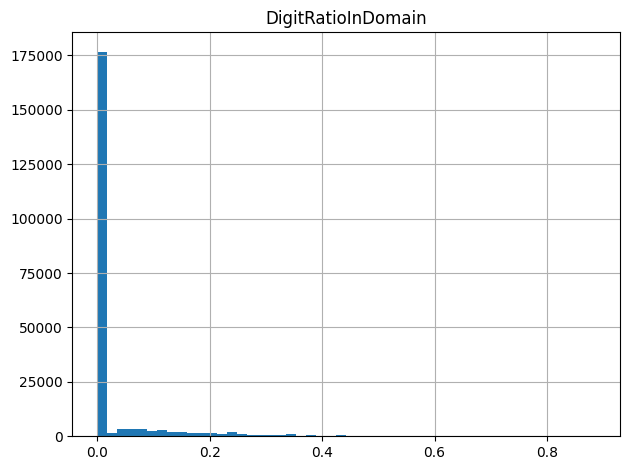

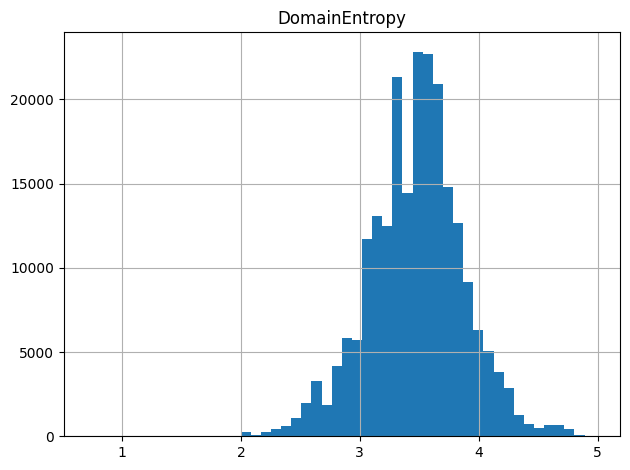

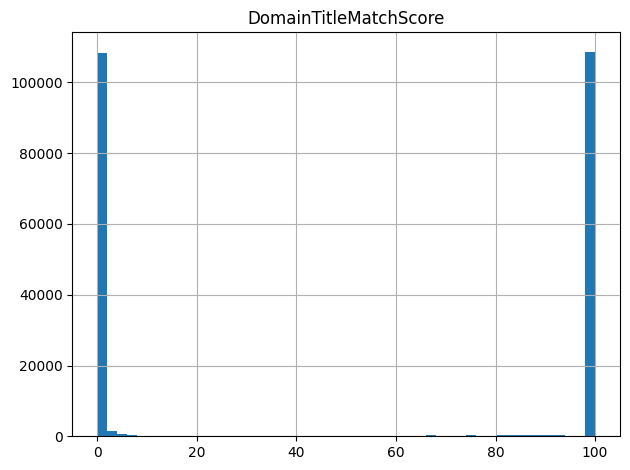

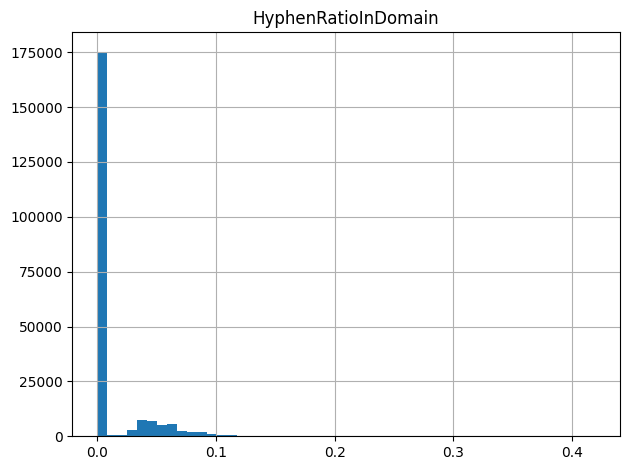

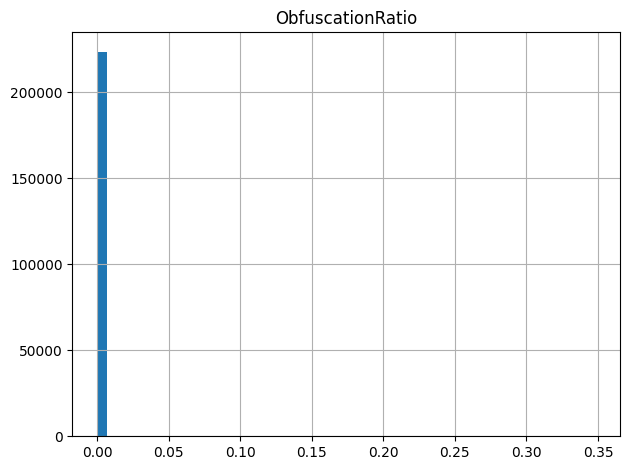

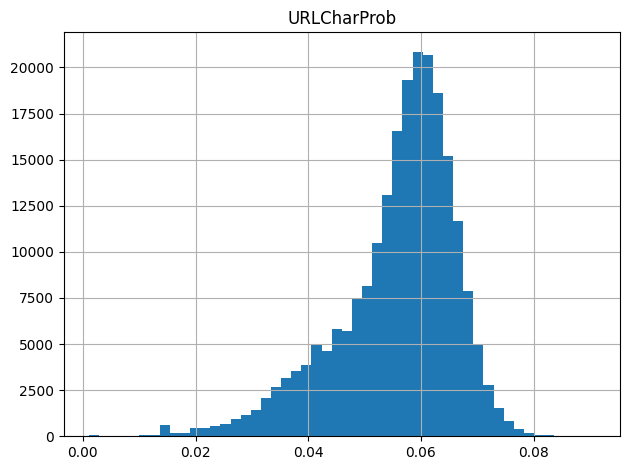

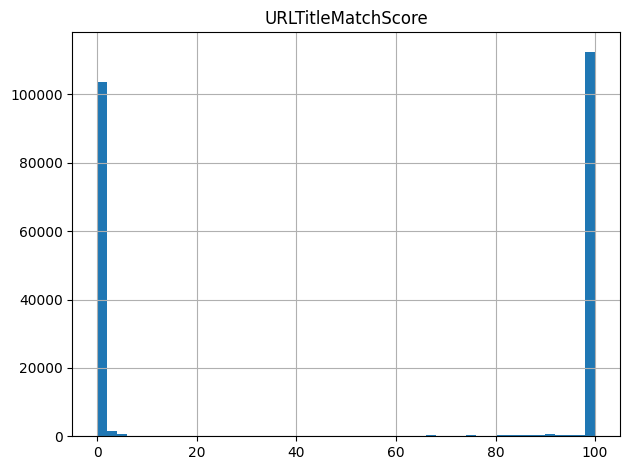

In [18]:
for col in float_columns:
    plt.figure()
    data[col].hist(bins=50)
    plt.title(col)
    plt.tight_layout()
    plt.show()

In [19]:
data["HasCharContinuation"] = (data["CharContinuationRate"] > 1.0 - 1e-6).astype("Int8")

data["HasDigitInDomain"] = (data["DigitRatioInDomain"] < 0.0 + 1e-6).astype("Int8")

# We can also take > 0.5 to be 1, but we care more if the title matches.
data["HasDomainTitleMatch"] = (data["DomainTitleMatchScore"] > 1.0 - 1e-6).astype("Int8")

data["HasHyphenInDomain"] = (data["HyphenRatioInDomain"] > 0.0 + 1e-6).astype("Int8")

data["HasObfuscation"] = (data["ObfuscationRatio"] > 0.0 + 1e-6).astype("Int8")

data["HasURLTitleMatch"] = (data["URLTitleMatchScore"] > 1.0 - 1e-6).astype("Int8")

columns_to_remove = [
    "CharContinuationRate",
    "DigitRatioInDomain",
    "DomainTitleMatchScore",
    "HyphenRatioInDomain",
    "ObfuscationRatio",
    "URLTitleMatchScore",
]

float_columns = np.setdiff1d(
    float_columns,
    columns_to_remove,
)

binary_columns = np.union1d(
    binary_columns,
    [
        "HasCharContinuation",
        "HasDigitInDomain",
        "HasDomainTitleMatch",
        "HasHyphenInDomain",
        "HasObfuscation",
        "HasURLTitleMatch",
    ],
)

data = data.drop(columns=columns_to_remove)

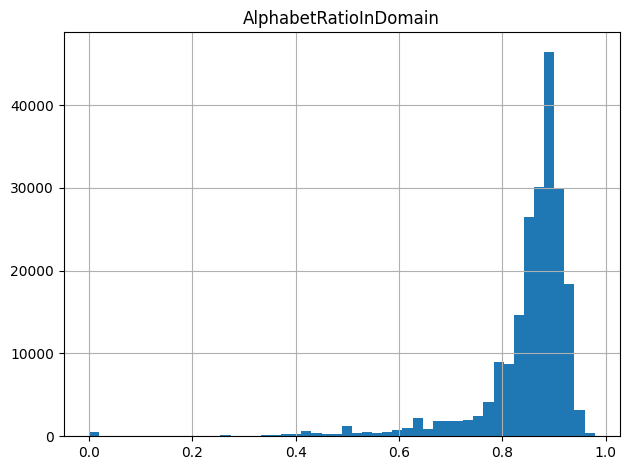

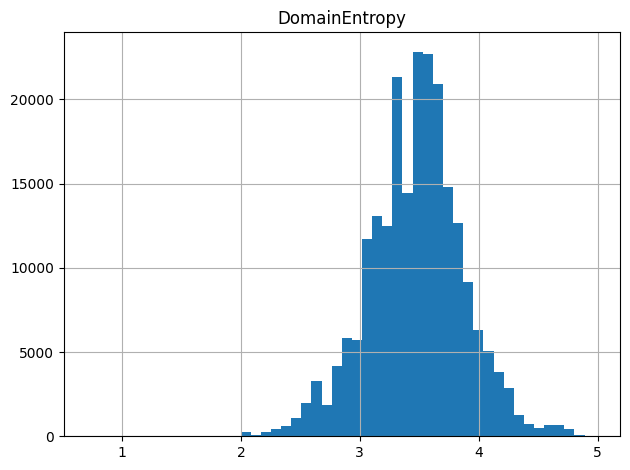

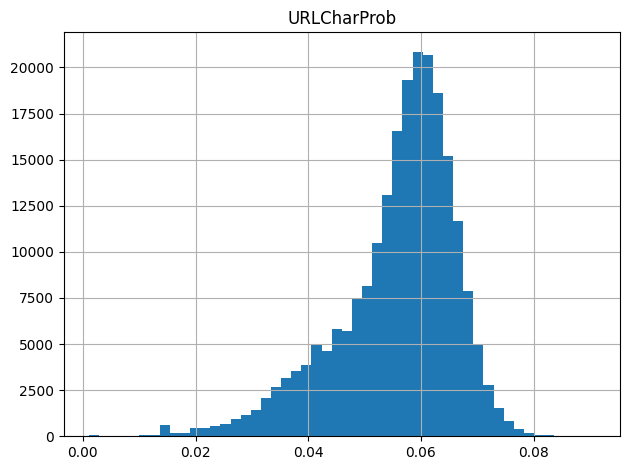

In [20]:
for col in float_columns:
    plt.figure()
    data[col].hist(bins=50)
    plt.title(col)
    plt.tight_layout()
    plt.show()

# Train/Test split

In [21]:
from sklearn.model_selection import train_test_split

data = data.dropna(subset=["label"])

X = data.drop(columns=["label"])
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0,
    stratify=y,
)

# TLD encoding

In [22]:
from category_encoders import TargetEncoder

encoder = TargetEncoder(
    cols=["TLD"],
    smoothing=100,
    min_samples_leaf=1,
)

encoder.fit(X_train["TLD"], y_train)

X_train["TLD"] = encoder.transform(X_train["TLD"])["TLD"]
X_test["TLD"] = encoder.transform(X_test["TLD"])["TLD"]

object_columns = np.setdiff1d(object_columns, ["TLD"])
float_columns = np.union1d(float_columns, ["TLD"])

# MICE imputation

In [23]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice = IterativeImputer(max_iter=10, random_state=0)

X_train_ = X_train.drop(columns=object_columns)
X_test_ = X_test.drop(columns=object_columns)

mice.fit(X_train_)

X_mice_train = mice.transform(X_train_)
X_mice_test = mice.transform(X_test_)

X_mice_train = pd.DataFrame(X_mice_train, columns=X_train_.columns, index=X_train_.index)
X_mice_test = pd.DataFrame(X_mice_test, columns=X_test_.columns, index=X_test_.index)

X_mice_train = pd.concat((X_mice_train, X_train[object_columns]), axis=1)
X_mice_test = pd.concat((X_mice_test, X_test[object_columns]), axis=1)

X_mice = pd.concat((X_mice_train, X_mice_test), axis=0)

X_mice.describe().T

,count,mean,std,min,25%,50%,75%,max
DomainLength,224012.0,21.504122,9.113593,-18.320753,16.000000,20.000000,24.117037,1.100000e+02
IsDomainIP,224012.0,0.002420,0.049129,0.000000,0.000000,0.000000,0.000000,1.000000e+00
TLD,224012.0,0.572634,0.256125,0.000349,0.536565,0.610847,0.631952,9.998825e-01
URLCharProb,224012.0,0.055743,0.010447,0.000853,0.050932,0.057935,0.062656,9.082366e-02
TLDLength,224012.0,2.617954,0.846253,0.000000,2.000000,3.000000,3.000000,1.300000e+01
NoOfSubDomain,224012.0,1.101401,0.638830,0.000000,1.000000,1.000000,1.000000,1.000000e+01
HasObfuscation,224012.0,0.001920,0.043771,0.000000,0.000000,0.000000,0.000000,1.000000e+00
NoOfObfuscatedChar,224012.0,0.024498,1.822679,-0.284847,0.000000,0.000000,0.000000,4.470000e+02
IsHTTPS,224012.0,0.741590,0.437762,0.000000,0.000000,1.000000,1.000000,1.000000e+00
LineOfCode,224012.0,1145.561847,3452.608644,-628.085598,18.000000,439.000000,1301.000000,4.426660e+05


In [24]:
# Discrete columns
X_mice[discrete_columns] = X_mice[discrete_columns].round().astype("Int64").clip(lower=0)

# Floating point columns
X_mice[float_columns] = X_mice[float_columns].clip(
    lower=X_train[float_columns].min(),
    upper=X_train[float_columns].max(),
    axis=1,
)

# Binary columns
binary_columns_ = np.setdiff1d(binary_columns, ["label"])
X_mice[binary_columns_] = (X_mice[binary_columns_] > 0.5).astype("Int8")

In [25]:
X_mice_train = X_mice.loc[X_train.index]
X_mice_test = X_mice.loc[X_test.index]

data_train = pd.concat((X_mice_train, y_train), axis=1)
data_test = pd.concat((X_mice_test, y_test), axis=1)
data = pd.concat((data_train, data_test), axis=0)

# Fixing Balance

In [26]:
data["label"].describe()

count    224012.0
mean     0.572054
std      0.494782
min           0.0
25%           0.0
50%           1.0
75%           1.0
max           1.0
Name: label, dtype: Float64

About 57% of the data are for legitimate sites. We have an imbalance problem, but not too severe. We can apply undersampling on the majority class. But, the balance is good as it is.

# Export

In [27]:
def rename(df):
    df = df.rename(columns={col: "B" + col for col in binary_columns})
    df = df.rename(columns={col: "D" + col for col in discrete_columns})
    df = df.rename(columns={col: "O" + col for col in object_columns})
    df = df.rename(columns={col: "F" + col for col in float_columns})

    df = df.rename(columns={"Blabel": "label"})

    return df


rename(data).to_csv("feature-engineering.csv", index=False)
rename(data_train).to_csv("feature-engineering-train.csv", index=False)
rename(data_test).to_csv("feature-engineering-test.csv", index=False)

In [28]:
data.loc[data["DomainEntropy"] == 0.0, "Domain"]

Series([], Name: Domain, dtype: object)